<a href="https://colab.research.google.com/github/Jenny-Tanananya/Project/blob/main/Step0_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import sklearn.model_selection
from sklearn.impute import SimpleImputer

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Project_CE/heart_disease.csv')
df = pd.DataFrame(df)
df

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [ ]:
df.isna().sum(axis='index')

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [ ]:
print(df.describe())

               Age  Blood Pressure  Cholesterol Level          BMI  \
count  9971.000000     9981.000000        9970.000000  9978.000000   
mean     49.296259      149.757740         225.425577    29.077269   
std      18.193970       17.572969          43.575809     6.307098   
min      18.000000      120.000000         150.000000    18.002837   
25%      34.000000      134.000000         187.000000    23.658075   
50%      49.000000      150.000000         226.000000    29.079492   
75%      65.000000      165.000000         263.000000    34.520015   
max      80.000000      180.000000         300.000000    39.996954   

       Sleep Hours  Triglyceride Level  Fasting Blood Sugar    CRP Level  \
count  9975.000000         9974.000000          9978.000000  9974.000000   
mean      6.991329          250.734409           120.142213     7.472201   
std       1.753195           87.067226            23.584011     4.340248   
min       4.000605          100.000000            80.000000     0

In [ ]:
df.dtypes

,0
Age,float64
Gender,object
Blood Pressure,float64
Cholesterol Level,float64
Exercise Habits,object
Smoking,object
Family Heart Disease,object
Diabetes,object
BMI,float64
High Blood Pressure,object


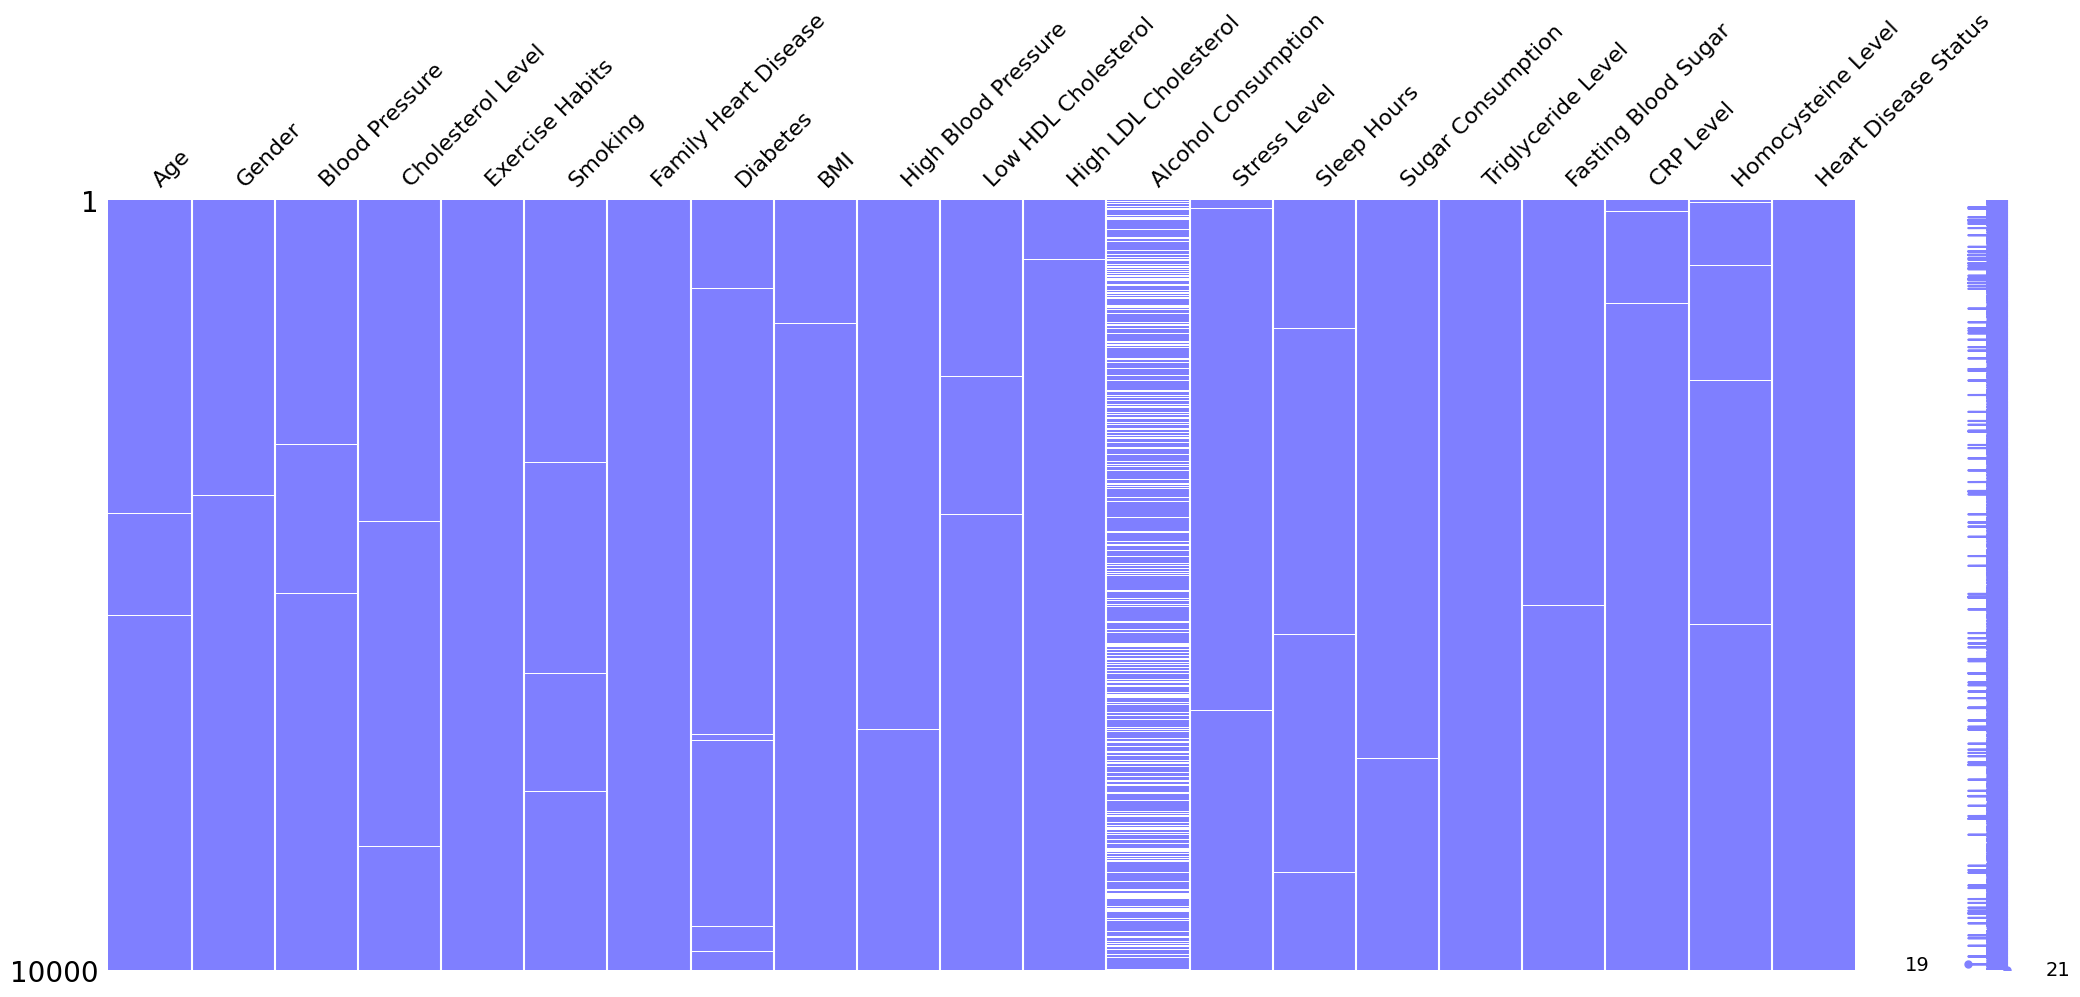

In [ ]:
msno.matrix(df, color=(0.5, 0.5, 1))
plt.show()

# Cap outliers
 เป็นจำกัดค่าให้ไม่เกินขอบเขต

Cap outliers in specified columns using IQR method based on provided percentiles.
### Parameters:
* df (pd.DataFrame): The dataframe containing the data.
* columns (list): List of column names to apply capping.
* lower_percentile (float): Lower percentile (default 0.05).
* upper_percentile (float): Upper percentile (default 0.95).

### Returns:
* pd.DataFrame: Modified dataframe with capped values.

In [ ]:
def cap_outiers_for_column(df, columns, lower_percentile=0.05, upper_percentile=0.95):
    for column in columns:
      if column in df.columns and pd.api.types.is_numeric_dtype(df[column]):
        Q1 = df[column].quantile(lower_percentile)
        Q3 = df[column].quantile(upper_percentile)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

#Categorical
  เลือกตัวที่ object ออกมาจาก dataset เพื่อที่จะได้กำจัด missing value โดยใช้ SimpleIputer (most frequent) และเปลี่ยนค่ะเป็น num โดยการใช้ binary encoding

In [ ]:
categorical_features = [
    'Gender',
    'Exercise Habits',
    'Smoking',
    'Family Heart Disease',
    'Diabetes',
    'High Blood Pressure',
    'Low HDL Cholesterol',
    'High LDL Cholesterol',
    'Stress Level',
    'Sugar Consumption',
    'Alcohol Consumption',
    'Heart Disease Status'
]
for feature in categorical_features:
    possible_values = df[feature].unique()
    print(f"Possible values for {feature}: {possible_values}")

Possible values for Gender: ['Male' 'Female' nan]
Possible values for Exercise Habits: ['High' 'Low' 'Medium' nan]
Possible values for Smoking: ['Yes' 'No' nan]
Possible values for Family Heart Disease: ['Yes' 'No' nan]
Possible values for Diabetes: ['No' 'Yes' nan]
Possible values for High Blood Pressure: ['Yes' 'No' nan]
Possible values for Low HDL Cholesterol: ['Yes' 'No' nan]
Possible values for High LDL Cholesterol: ['No' 'Yes' nan]
Possible values for Stress Level: ['Medium' 'High' 'Low' nan]
Possible values for Sugar Consumption: ['Medium' 'Low' 'High' nan]
Possible values for Alcohol Consumption: ['High' 'Medium' 'Low' nan]
Possible values for Heart Disease Status: ['No' 'Yes']


In [ ]:
df_categorical = df[categorical_features]
df_categorical

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Stress Level,Sugar Consumption,Alcohol Consumption,Heart Disease Status
0,Male,High,Yes,Yes,No,Yes,Yes,No,Medium,Medium,High,No
1,Female,High,No,Yes,Yes,No,Yes,No,High,Medium,Medium,No
2,Male,Low,No,No,No,No,Yes,Yes,Low,Low,Low,No
3,Female,High,Yes,Yes,No,Yes,No,Yes,High,High,Low,No
4,Male,Low,Yes,Yes,Yes,Yes,No,No,High,High,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Female,Medium,Yes,No,No,Yes,No,Yes,High,Medium,Medium,Yes
9996,Male,Medium,No,No,No,Yes,No,Yes,High,Low,NaN,Yes
9997,Male,High,Yes,No,Yes,No,Yes,Yes,Low,Low,NaN,Yes
9998,Male,Low,Yes,No,Yes,Yes,No,Yes,High,Medium,Medium,Yes


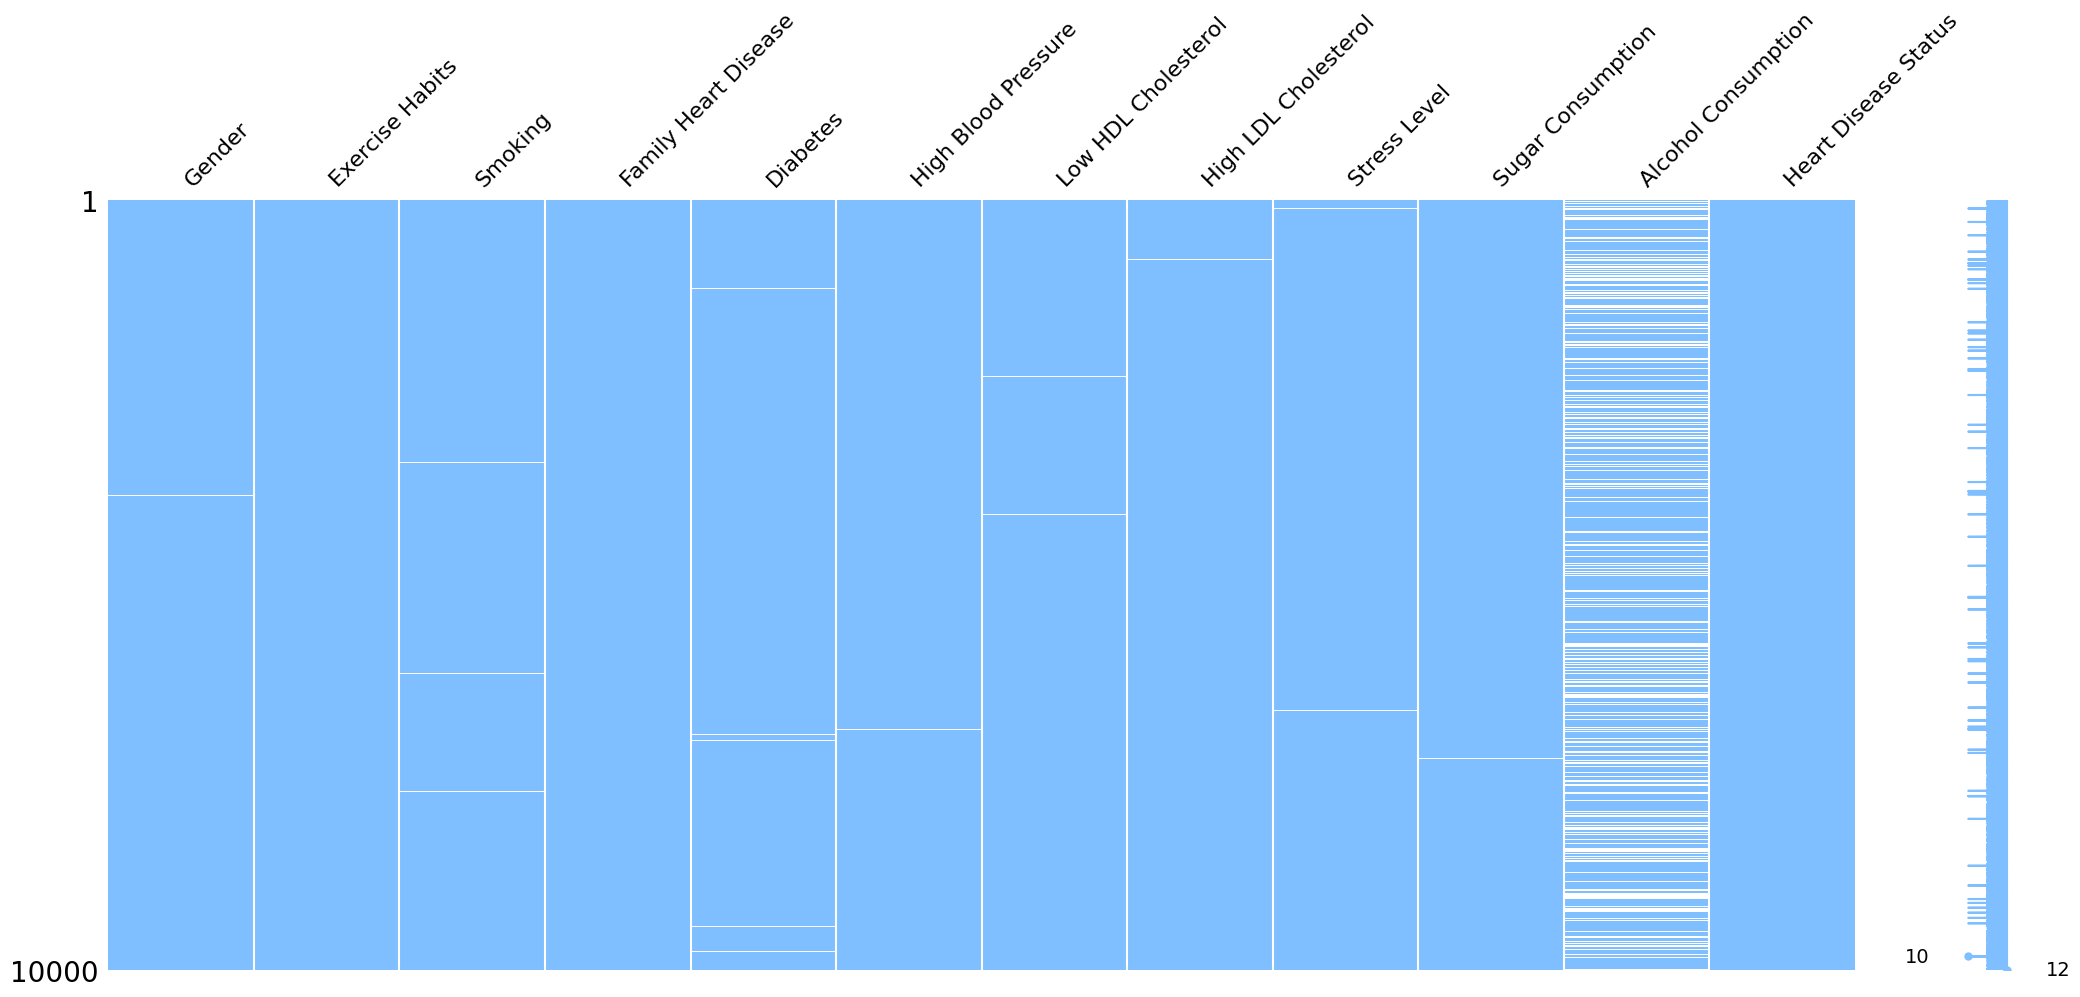

In [ ]:
msno.matrix(df_categorical, color=(0.5, 0.75, 1))
plt.show()

In [ ]:
categorical_imputer = SimpleImputer(strategy='most_frequent')
categorical_imputer.fit(df_categorical)

SimpleImputer(strategy='most_frequent')

In [ ]:
df_categorical = pd.DataFrame(
    data = categorical_imputer.transform(df_categorical),
    columns = categorical_imputer.get_feature_names_out(),
    index = df_categorical.index
)
df_categorical

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Stress Level,Sugar Consumption,Alcohol Consumption,Heart Disease Status
0,Male,High,Yes,Yes,No,Yes,Yes,No,Medium,Medium,High,No
1,Female,High,No,Yes,Yes,No,Yes,No,High,Medium,Medium,No
2,Male,Low,No,No,No,No,Yes,Yes,Low,Low,Low,No
3,Female,High,Yes,Yes,No,Yes,No,Yes,High,High,Low,No
4,Male,Low,Yes,Yes,Yes,Yes,No,No,High,High,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Female,Medium,Yes,No,No,Yes,No,Yes,High,Medium,Medium,Yes
9996,Male,Medium,No,No,No,Yes,No,Yes,High,Low,Medium,Yes
9997,Male,High,Yes,No,Yes,No,Yes,Yes,Low,Low,Medium,Yes
9998,Male,Low,Yes,No,Yes,Yes,No,Yes,High,Medium,Medium,Yes


In [ ]:
df_categorical.isna().sum(axis='index')

,0
Gender,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
High Blood Pressure,0
Low HDL Cholesterol,0
High LDL Cholesterol,0
Stress Level,0
Sugar Consumption,0


In [ ]:
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_categorical['Exercise Habits'] = df_categorical['Exercise Habits'].map(ordinal_map)
df_categorical['Stress Level'] = df_categorical['Stress Level'].map(ordinal_map)
df_categorical['Alcohol Consumption'] = df_categorical['Alcohol Consumption'].map(ordinal_map)
df_categorical['Sugar Consumption'] = df_categorical['Sugar Consumption'].map(ordinal_map)

In [ ]:
yesno_map = {'No': 0, 'Yes': 1}
df_categorical['Smoking'] = df_categorical['Smoking'].map(yesno_map)
df_categorical['Diabetes'] = df_categorical['Diabetes'].map(yesno_map)
df_categorical['Family Heart Disease'] = df_categorical['Family Heart Disease'].map(yesno_map)
df_categorical['High Blood Pressure'] = df_categorical['High Blood Pressure'].map(yesno_map)
df_categorical['Low HDL Cholesterol'] = df_categorical['Low HDL Cholesterol'].map(yesno_map)
df_categorical['High LDL Cholesterol'] = df_categorical['High LDL Cholesterol'].map(yesno_map)

In [ ]:
gender_map = {'Female': 0, 'Male': 1}
df_categorical['Gender'] = df_categorical['Gender'].map(gender_map)

In [ ]:
df_categorical

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Stress Level,Sugar Consumption,Alcohol Consumption,Heart Disease Status
0,1,2,1,1,0,1,1,0,1,1,2,No
1,0,2,0,1,1,0,1,0,2,1,1,No
2,1,0,0,0,0,0,1,1,0,0,0,No
3,0,2,1,1,0,1,0,1,2,2,0,No
4,1,0,1,1,1,1,0,0,2,2,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,1,1,0,0,1,0,1,2,1,1,Yes
9996,1,1,0,0,0,1,0,1,2,0,1,Yes
9997,1,2,1,0,1,0,1,1,0,0,1,Yes
9998,1,0,1,0,1,1,0,1,2,1,1,Yes


#Numerical
 เลือกเฉพาะข้อมูลที่เป็น num มาเพื่อกำจัดค่า missing value โดยวิธีการ SimpleInput (Mean) และทำค่า ให้เป็นค่า Standard

In [ ]:
numerical_features = [
    'Age',
    'Blood Pressure',
    'Cholesterol Level',
    'BMI',
    'Sleep Hours',
    'Triglyceride Level',
    'Fasting Blood Sugar',
    'CRP Level',
    'Homocysteine Level'
]

In [ ]:
df_numerical = df[numerical_features]
df_numerical

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,56.0,153.0,155.0,24.991591,7.633228,342.0,NaN,12.969246,12.387250
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.0,9.355389,19.298875
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.0,12.709873,11.230926
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.0,12.509046,5.961958
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.0,10.381259,8.153887
...,...,...,...,...,...,...,...,...,...
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.0,3.588814,19.132004
9996,38.0,172.0,154.0,31.856801,8.247784,377.0,83.0,2.658267,9.715709
9997,73.0,152.0,201.0,26.899911,4.436762,248.0,88.0,4.408867,9.492429
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.0,7.215634,11.873486


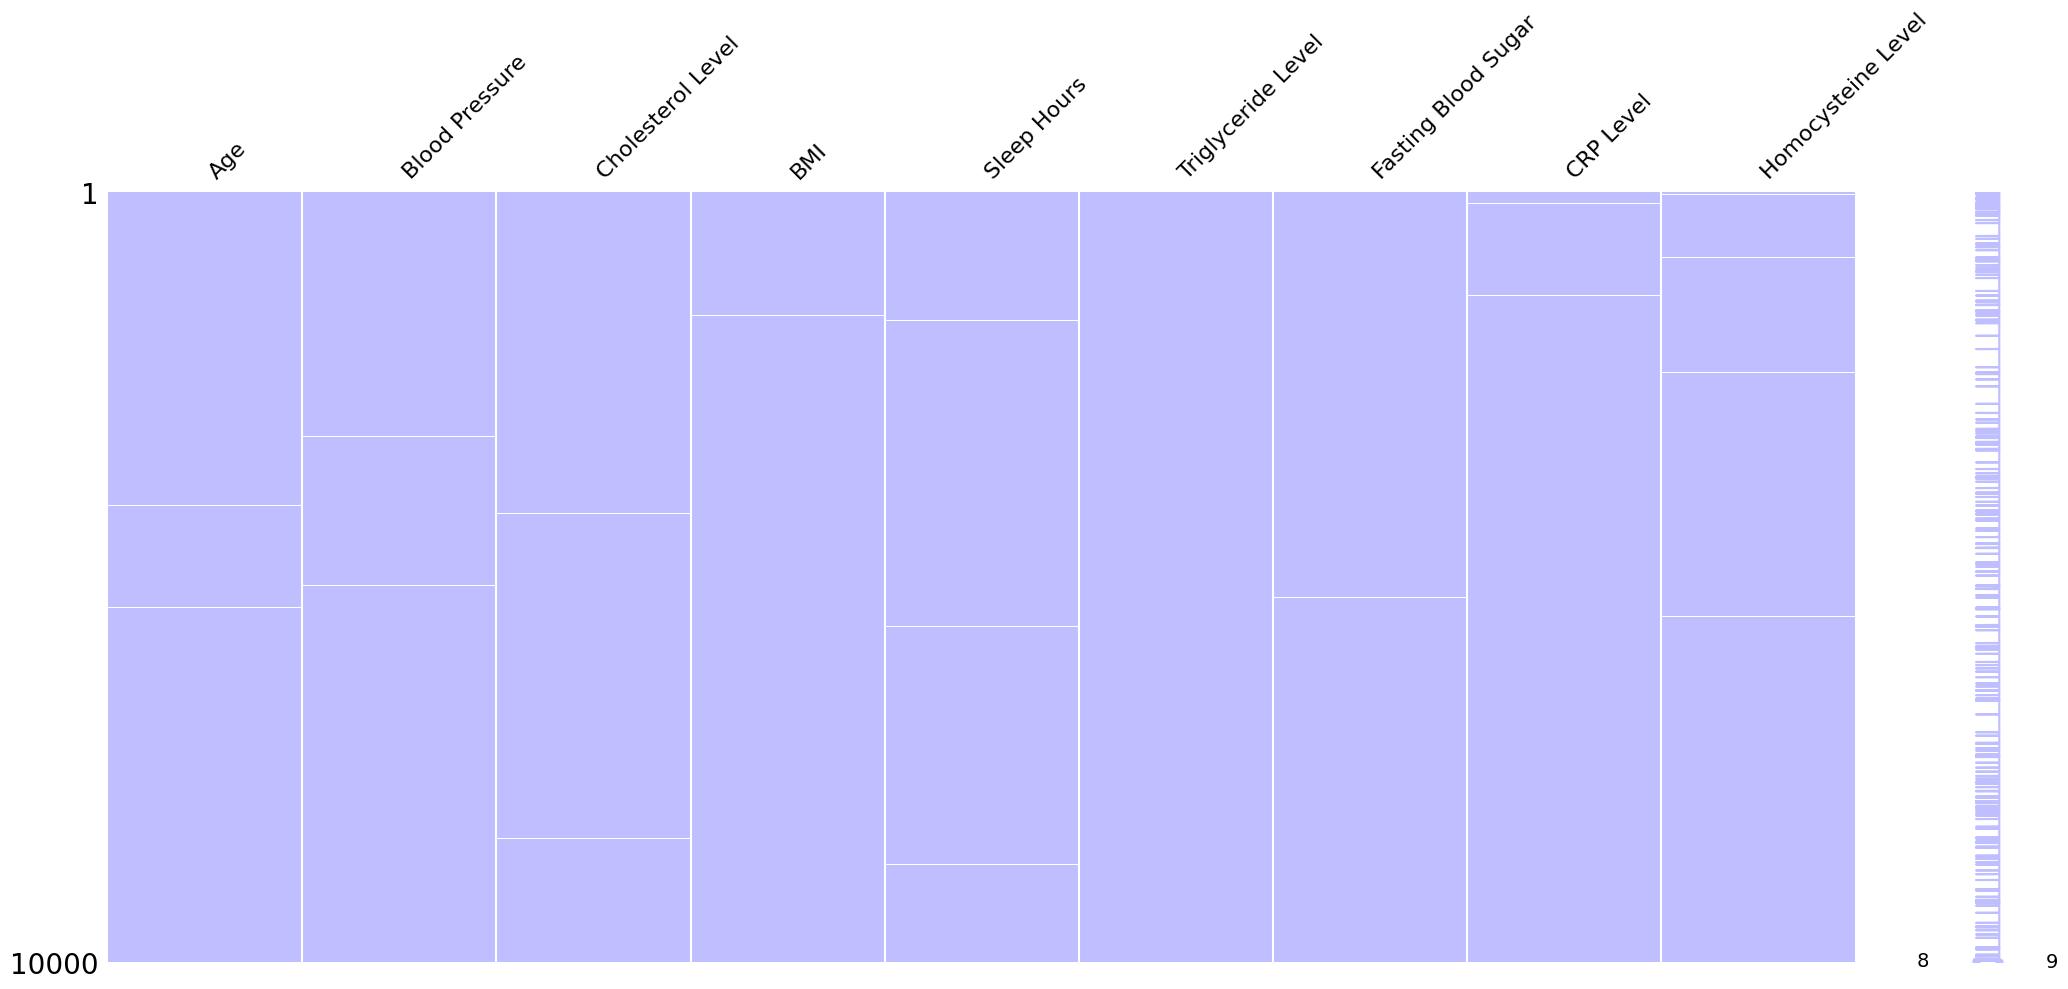

In [ ]:
msno.matrix(df_numerical, color=(0.75, 0.75, 1))
plt.show()

In [ ]:
numerical_imputer = SimpleImputer(strategy='mean')
numerical_imputer.fit(df_numerical)

SimpleImputer()

In [ ]:
df_numerical = pd.DataFrame(
    data = numerical_imputer.transform(df_numerical),
    columns = numerical_imputer.get_feature_names_out(),
    index = df_numerical.index
)
df_numerical

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,56.0,153.0,155.0,24.991591,7.633228,342.0,120.142213,12.969246,12.387250
1,69.0,146.0,286.0,25.221799,8.744034,133.0,157.000000,9.355389,19.298875
2,46.0,126.0,216.0,29.855447,4.440440,393.0,92.000000,12.709873,11.230926
3,32.0,122.0,293.0,24.130477,5.249405,293.0,94.000000,12.509046,5.961958
4,60.0,166.0,242.0,20.486289,7.030971,263.0,154.000000,10.381259,8.153887
...,...,...,...,...,...,...,...,...,...
9995,25.0,136.0,243.0,18.788791,6.834954,343.0,133.000000,3.588814,19.132004
9996,38.0,172.0,154.0,31.856801,8.247784,377.0,83.000000,2.658267,9.715709
9997,73.0,152.0,201.0,26.899911,4.436762,248.0,88.000000,4.408867,9.492429
9998,23.0,142.0,299.0,34.964026,8.526329,113.0,153.000000,7.215634,11.873486


In [ ]:
df_numerical.isna().sum(axis='index')

,0
Age,0
Blood Pressure,0
Cholesterol Level,0
BMI,0
Sleep Hours,0
Triglyceride Level,0
Fasting Blood Sugar,0
CRP Level,0
Homocysteine Level,0


In [ ]:
standard_scaler = sklearn.preprocessing.StandardScaler()
standard_scaler.fit(df_numerical)

StandardScaler()

In [ ]:
df_numerical = pd.DataFrame(
    data = standard_scaler.transform(df_numerical),
    columns = standard_scaler.get_feature_names_out(),
    index = df_numerical.index
)
df_numerical

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
0,0.369013,0.184687,-1.618673,-0.648537,0.366608,1.049638,0.000000,1.268241,-0.015981
1,1.084610,-0.214051,1.392253,-0.611995,1.001022,-1.354053,1.564630,0.434477,1.584346
2,-0.181446,-1.353302,-0.216639,0.123523,-1.456890,1.636184,-1.194650,1.208400,-0.283718
3,-0.952088,-1.581152,1.553142,-0.785225,-0.994866,0.486093,-1.109749,1.162067,-1.503702
4,0.589197,0.925201,0.380949,-1.363682,0.022641,0.141066,1.437278,0.671158,-0.996180
...,...,...,...,...,...,...,...,...,...
9995,-1.337409,-0.783676,0.403933,-1.633133,-0.089310,1.061139,0.545819,-0.895949,1.545708
9996,-0.621813,1.266976,-1.641657,0.441207,0.717599,1.452170,-1.576704,-1.110638,-0.634553
9997,1.304794,0.127725,-0.561401,-0.345621,-1.458990,-0.031448,-1.364452,-0.706752,-0.686252
9998,-1.447501,-0.441901,1.691047,0.934429,0.876684,-1.584072,1.394828,-0.059193,-0.134939


#Label Encoder
 เราต้องการที่จะแปลงค่า Heart Disease Status เป็นตัวเลข เนื่องจากเป็น Column ในส่วน target  จึงเลือกใช้ Label encoder ในการแปลงค่า

In [ ]:
label_encoder = sklearn.preprocessing.LabelEncoder()
label_encoder.fit(df['Heart Disease Status'])

LabelEncoder()

In [ ]:
df_label = pd.DataFrame(
    data = label_encoder.transform(df['Heart Disease Status']),
    columns = ['Heart Disease Status'],
    index = df.index
)
df_label

,Heart Disease Status
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,1
9997,1
9998,1


In [ ]:
df_categorical = df_categorical.drop(columns=['Heart Disease Status'], errors='ignore')
df = df_categorical.join(df_numerical).join(df_label)
df

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Stress Level,Sugar Consumption,...,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,1,2,1,1,0,1,1,0,1,1,...,0.369013,0.184687,-1.618673,-0.648537,0.366608,1.049638,0.000000,1.268241,-0.015981,0
1,0,2,0,1,1,0,1,0,2,1,...,1.084610,-0.214051,1.392253,-0.611995,1.001022,-1.354053,1.564630,0.434477,1.584346,0
2,1,0,0,0,0,0,1,1,0,0,...,-0.181446,-1.353302,-0.216639,0.123523,-1.456890,1.636184,-1.194650,1.208400,-0.283718,0
3,0,2,1,1,0,1,0,1,2,2,...,-0.952088,-1.581152,1.553142,-0.785225,-0.994866,0.486093,-1.109749,1.162067,-1.503702,0
4,1,0,1,1,1,1,0,0,2,2,...,0.589197,0.925201,0.380949,-1.363682,0.022641,0.141066,1.437278,0.671158,-0.996180,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,1,1,0,0,1,0,1,2,1,...,-1.337409,-0.783676,0.403933,-1.633133,-0.089310,1.061139,0.545819,-0.895949,1.545708,1
9996,1,1,0,0,0,1,0,1,2,0,...,-0.621813,1.266976,-1.641657,0.441207,0.717599,1.452170,-1.576704,-1.110638,-0.634553,1
9997,1,2,1,0,1,0,1,1,0,0,...,1.304794,0.127725,-0.561401,-0.345621,-1.458990,-0.031448,-1.364452,-0.706752,-0.686252,1
9998,1,0,1,0,1,1,0,1,2,1,...,-1.447501,-0.441901,1.691047,0.934429,0.876684,-1.584072,1.394828,-0.059193,-0.134939,1


In [ ]:
df.isna().sum(axis='index')

,0
Gender,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
High Blood Pressure,0
Low HDL Cholesterol,0
High LDL Cholesterol,0
Stress Level,0
Sugar Consumption,0


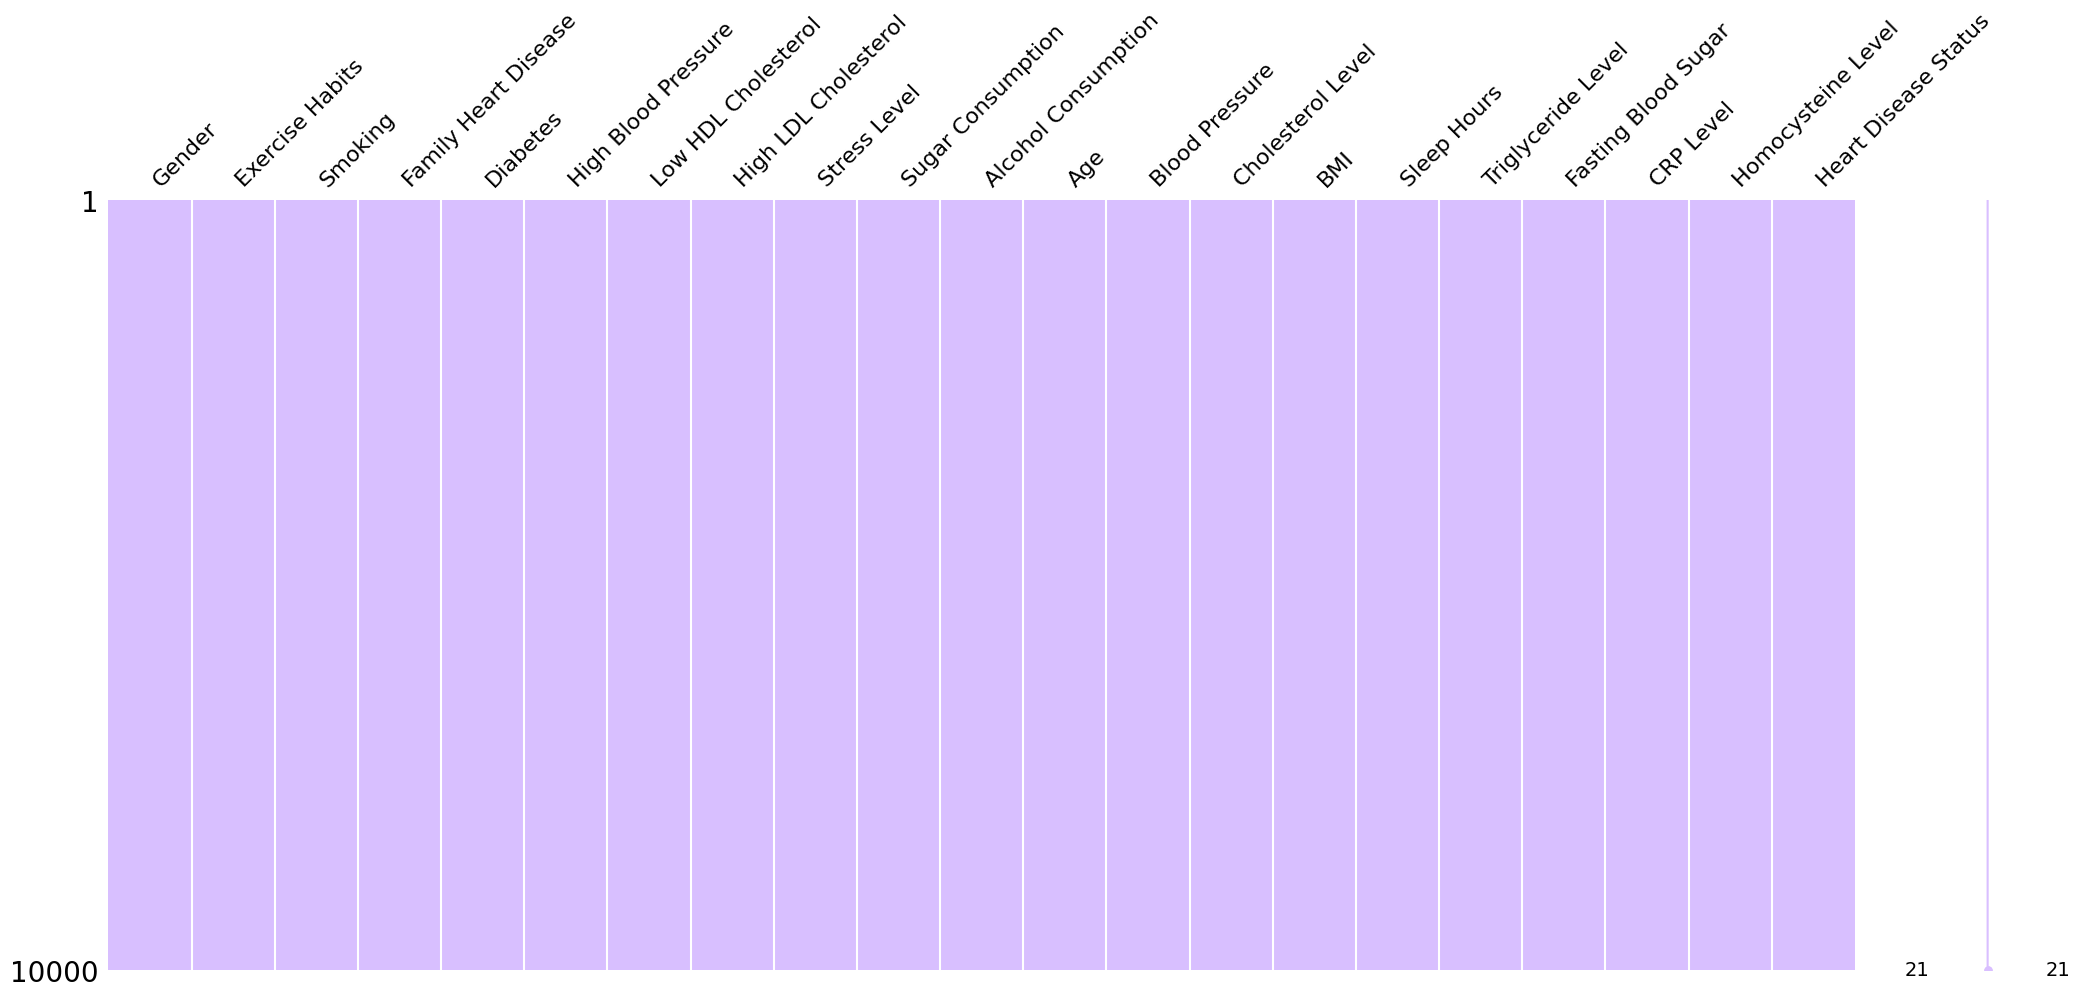

In [ ]:
msno.matrix(df, color=(0.85, 0.75, 1))
plt.show()

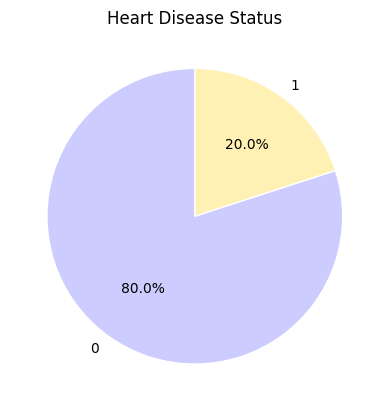

In [ ]:
HDS = df["Heart Disease Status"].value_counts()
HDS.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#CCCCFF','#fff0b3'], wedgeprops={'edgecolor': '#ffffff', 'linewidth': 1})
plt.title('Heart Disease Status')
plt.ylabel('')
plt.show()

In [ ]:
df.to_csv('/content/drive/MyDrive/Project_CE/heart_disease_clean.csv', index=False)